In [1]:
import pandas as pd
import numpy as np

In [55]:
X = pd.read_csv("../data/processed_X.csv")
y = pd.read_csv("../data/target_y.csv")

In [3]:
print(X.shape)
print(y.shape)

(1337, 8)
(1337, 1)


In [4]:
y = y.squeeze()

In [5]:
print(type(y))

<class 'pandas.Series'>


# train test Split

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1069, 8)
X_test : (268, 8)
y_train: (1069,)
y_test : (268,)


The dataset was split into training and testing sets using an 80:20 ratio. The training set is used to learn patterns from the data, while the testing set is used to evaluate the model's performance on unseen data.

In [9]:
print(X_train.head())

      age  sex     bmi  children  smoker  region_northwest  region_southeast  \
1113   23    1  24.510         0       0                 0                 0   
967    21    1  25.745         2       0                 0                 0   
598    52    0  37.525         2       0                 1                 0   
170    63    1  41.470         0       0                 0                 1   
275    47    0  26.600         2       0                 0                 0   

      region_southwest  
1113                 0  
967                  0  
598                  0  
170                  0  
275                  0  


In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()

In [12]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 248.21,-101.54, 318.7 ,...,-391.76,-838.92,-659.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.109e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [13]:
y_pred = lr.predict(X_test)

In [14]:
pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

pred_df.head()

,Actual,Predicted
899,8688.85885,8143.693884
1063,5708.86700,5737.115683
1255,11436.73815,14369.314876
298,38746.35510,31745.513636
237,4463.20510,8962.386657


In [15]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [16]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4177.045561036318


In [17]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 35478020.67523558


In [18]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 5956.342894363585


In [19]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8069287081198013


In [20]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
4,smoker,23077.764593
3,children,533.009989
2,bmi,318.701441
0,age,248.210720
1,sex,-101.542054
5,region_northwest,-391.761455
7,region_southwest,-659.139752
6,region_southeast,-838.919616


In [21]:
print("Intercept:", lr.intercept_)

Intercept: -11092.652295945958


In [24]:
!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.7 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.5 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.5 MB 1.6 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.5 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.7 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.5 MB 1.6 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.5 MB 1.6 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.5 MB 1.6 MB/s eta 0:00:05
   --------------- ------------

In [26]:
import statsmodels.api as sm

In [27]:
X_const = sm.add_constant(X)

In [28]:
ols_model = sm.OLS(y, X_const).fit()

In [29]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:35:12   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

In [30]:
residuals = y_test - y_pred

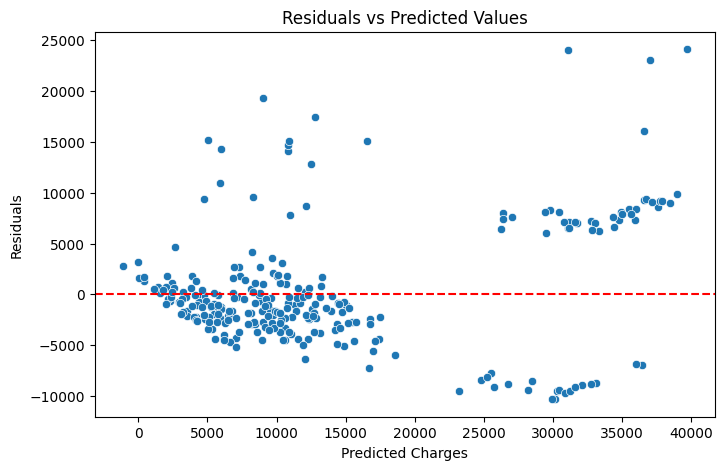

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

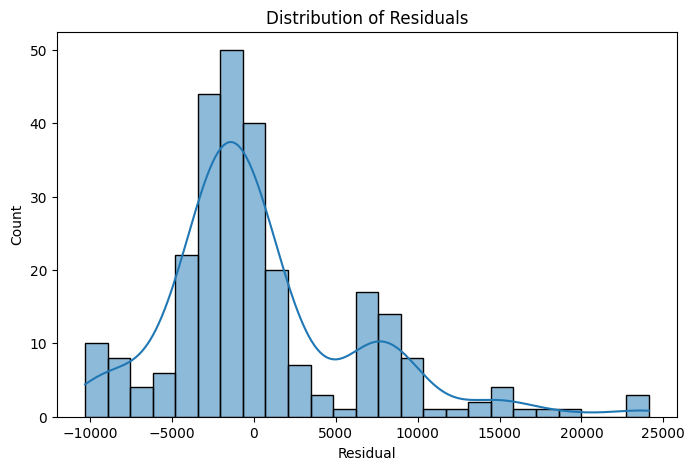

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")

plt.show()

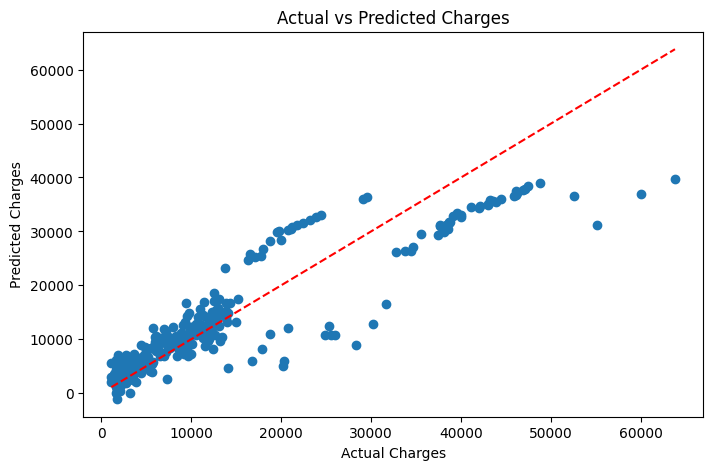

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

Project Conclusion
Objective

To predict medical insurance charges using demographic and health-related features through a Linear Regression model.

Dataset Overview
Total Records: 1337
Numerical Features: age, bmi, children
Categorical Features: sex, smoker, region
Target Variable: charges
Key EDA Findings
Insurance charges are right-skewed.
Smokers incur significantly higher insurance charges than non-smokers.
Age and BMI show a positive relationship with insurance charges.
Number of children has a relatively small effect on charges.
No major multicollinearity was observed among predictors.
Feature Engineering
Label Encoding applied to:
sex
smoker
One-Hot Encoding applied to:
region
Model Performance
MAE  = 4177.05
RMSE = 5956.34
R²   = 0.807

Interpretation:

The model explains approximately 80.7% of the variation in insurance charges and achieves a reasonable prediction error.

OLS Insights

Statistically Significant Features:

Age
BMI
Children
Smoker
Region Southeast
Region Southwest

Not Statistically Significant:

Sex
Region Northwest

Smoking status was identified as the strongest predictor of insurance charges.

Final Conclusion

Linear Regression performed well on the dataset and successfully captured the relationship between insurance charges and key factors such as smoking status, age, and BMI. The model explained over 80% of the variability in insurance charges, making it a strong baseline model for insurance cost prediction.

In [36]:
import pickle

with open("../models/linear_regression_model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("Model saved successfully")

Model saved successfully


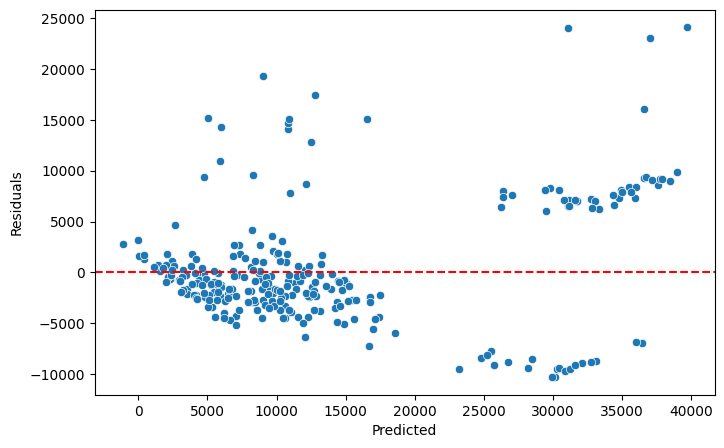

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.savefig("../images/residual_plot.png",
            bbox_inches="tight")

plt.show()

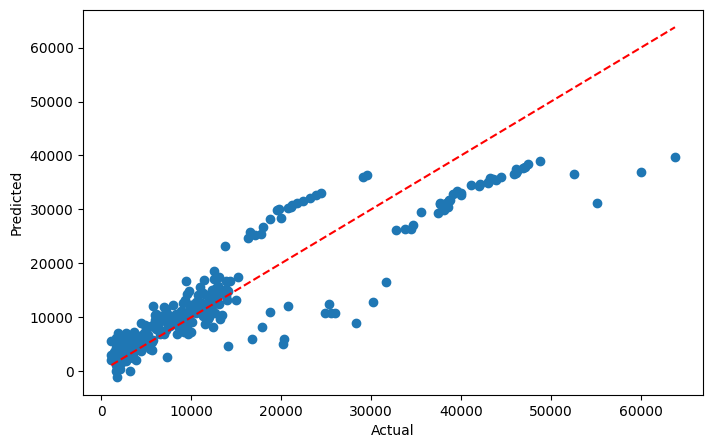

In [44]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.savefig("../images/actual_vs_predicted.png",
            bbox_inches="tight")

plt.show()

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import numpy as np


In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
lr_scaled = LinearRegression()

lr_scaled.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3472.98, -50.75,1927.83,...,-168.94,-371.78,-284.61]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.303e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[40.35,37.8 ,34.8 ,...,31.02,28.65,18.06]"


In [48]:
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [51]:
mae = mean_absolute_error(y_test, y_pred_scaled)

mse = mean_squared_error(y_test, y_pred_scaled)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_scaled)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 4177.045561036324
MSE : 35478020.67523558
RMSE: 5956.342894363585
R2  : 0.8069287081198013


In [52]:
with open("../models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully")

Scaler saved successfully


In [53]:
with open("../models/linear_regression_scaled.pkl", "wb") as file:
    pickle.dump(lr_scaled, file)

print("Scaled model saved successfully")

Scaled model saved successfully


In [54]:
coef_df_scaled = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_scaled.coef_
})

coef_df_scaled.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,smoker,9234.342487
0,age,3472.975553
2,bmi,1927.828251
3,children,636.501185
1,sex,-50.749675
5,region_northwest,-168.944439
7,region_southwest,-284.610396
6,region_southeast,-371.780810


### Effect of Feature Scaling

Feature scaling was performed using StandardScaler to standardize the numerical features before training the Linear Regression model.

After comparing the model performance before and after scaling, it was observed that the evaluation metrics remained almost unchanged.

This behavior is expected because Linear Regression is generally not sensitive to feature scaling. Scaling does not significantly affect the predictive performance of the model, but it helps bring all features to a common scale and makes coefficient comparison easier.

